# Machine Learning com Ações da Bolsa (BBAS3)

Este notebook demonstra como prever o preço de fechamento das ações do **Banco do Brasil (BBAS3)** utilizando redes neurais artificiais (`MLPRegressor`) com médias móveis como features.

**Fluxo geral:**
1. Coleta de dados históricos via `yfinance`
2. Limpeza e preparação dos dados
3. Engenharia de features (médias móveis)
4. Divisão treino / validação / teste
5. Normalização dos dados
6. Treinamento e avaliação do modelo
7. Visualização dos resultados

São demonstradas **duas abordagens**: sem normalizar o alvo `y`, e normalizando o alvo `y`.

## 1. Importação das bibliotecas

Importamos as principais ferramentas usadas ao longo do projeto:
- **`yfinance`**: baixar dados históricos de ações diretamente do Yahoo Finance.
- **`pandas`**: manipulação de DataFrames (tabelas de dados).
- **`numpy`**: operações numéricas e vetoriais.
- **`matplotlib.pyplot`**: geração de gráficos.

In [31]:
import yfinance as yF

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format="{:.2f}".format


## 2. Coleta dos dados históricos

Utilizamos o `yfinance` para baixar os últimos **10 anos** de dados diários da ação **BBAS3.SA** (Banco do Brasil, listada na B3).

O resultado é um DataFrame com colunas: `Date`, `Open`, `High`, `Low`, `Close`, `Volume`, `Dividends`, `Stock Splits`.

In [4]:
# Cria um objeto Ticker para a ação BBAS3 (Banco do Brasil, B3)
Cota = yF.Ticker("BBAS3.SA")

# Baixa o histórico dos últimos 10 anos de negociação
data = Cota.history(period="10y")

# Exibe as primeiras linhas para conferir a estrutura dos dados
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-06-01 00:00:00-03:00,4.44,4.52,4.37,4.49,21501400,0.00,0.00
2016-06-02 00:00:00-03:00,4.51,4.58,4.41,4.58,20070000,0.00,0.00
2016-06-03 00:00:00-03:00,4.61,4.71,4.57,4.69,19103800,0.00,0.00
2016-06-06 00:00:00-03:00,4.70,4.76,4.59,4.64,16916800,0.00,0.00
2016-06-07 00:00:00-03:00,4.59,4.71,4.57,4.59,14297000,0.00,0.00


## 3. Reset do índice

O `yfinance` retorna o DataFrame com a coluna `Date` como **índice**. Fazemos o reset para que ela vire uma coluna comum, facilitando o manuseio posterior.

In [5]:
# Transforma o índice 'Date' em coluna comum para facilitar manipulações futuras
data.reset_index(inplace=True)

data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2016-06-01 00:00:00-03:00,4.44,4.52,4.37,4.49,21501400,0.00,0.00
1,2016-06-02 00:00:00-03:00,4.51,4.58,4.41,4.58,20070000,0.00,0.00
2,2016-06-03 00:00:00-03:00,4.61,4.71,4.57,4.69,19103800,0.00,0.00
3,2016-06-06 00:00:00-03:00,4.70,4.76,4.59,4.64,16916800,0.00,0.00
4,2016-06-07 00:00:00-03:00,4.59,4.71,4.57,4.59,14297000,0.00,0.00


## 4. Verificação das últimas linhas

Exibimos as **últimas linhas** do DataFrame para verificar qual é a data mais recente disponível.

In [ ]:
# Exibe as últimas 5 linhas para conferir a data mais recente do histórico
data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
2487,2026-05-26 00:00:00-03:00,21.59,21.64,21.10,21.11,22798700,0.00,0.00
2488,2026-05-27 00:00:00-03:00,21.44,21.50,21.07,21.07,13716500,0.00,0.00
2489,2026-05-28 00:00:00-03:00,21.06,21.18,20.61,20.61,19444000,0.00,0.00
2490,2026-05-29 00:00:00-03:00,20.67,20.70,20.28,20.30,60512500,0.00,0.00
2491,2026-06-01 00:00:00-03:00,20.51,20.55,20.05,20.08,50093500,0.00,0.00


## 5. Remoção do dia atual (pregão em aberto)

O `yfinance` pode incluir o pregão do **dia corrente** (ainda em andamento), cujos valores são parciais/provisórios. Removemos essa última linha para evitar que dados incompletos contaminem o modelo.

In [7]:
# Remove a última linha (pregão do dia atual — pode estar incompleto)
data.drop(data.tail(1).index, inplace=True)

# Confirma a remoção exibindo as novas últimas linhas
data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
2486,2026-05-25 00:00:00-03:00,21.14,21.67,21.13,21.65,15414500,0.00,0.00
2487,2026-05-26 00:00:00-03:00,21.59,21.64,21.10,21.11,22798700,0.00,0.00
2488,2026-05-27 00:00:00-03:00,21.44,21.50,21.07,21.07,13716500,0.00,0.00
2489,2026-05-28 00:00:00-03:00,21.06,21.18,20.61,20.61,19444000,0.00,0.00
2490,2026-05-29 00:00:00-03:00,20.67,20.70,20.28,20.30,60512500,0.00,0.00


## 6. Remoção de colunas irrelevantes

As colunas `Dividends` e `Stock Splits` não serão usadas como features do modelo, pois não representam o comportamento de preço intradiário. Removemos para deixar o DataFrame mais limpo.

In [8]:
# Lista de colunas que não serão utilizadas no modelo
colunas = ["Dividends", "Stock Splits"]

# Remove as colunas da lista
data = data.drop(columns=colunas)

# Confirma as colunas restantes
data.head()

,Date,Open,High,Low,Close,Volume
0,2016-06-01 00:00:00-03:00,4.44,4.52,4.37,4.49,21501400
1,2016-06-02 00:00:00-03:00,4.51,4.58,4.41,4.58,20070000
2,2016-06-03 00:00:00-03:00,4.61,4.71,4.57,4.69,19103800
3,2016-06-06 00:00:00-03:00,4.70,4.76,4.59,4.64,16916800
4,2016-06-07 00:00:00-03:00,4.59,4.71,4.57,4.59,14297000


## 7. Verificação do intervalo de datas

Exibimos a menor e a maior data do dataset para confirmar o período coberto pelos dados.

In [9]:
# Exibe o intervalo de datas coberto pelo dataset
print('Menor data: ', data['Date'].min())
print('Maior data: ', data['Date'].max())

Menor data:  2016-06-01 00:00:00-03:00
Maior data:  2026-05-29 00:00:00-03:00


## 8. Inspeção do último registro

Filtramos a linha correspondente à data máxima para inspecionar o último pregão disponível.

In [10]:
# Filtra e exibe apenas a linha do último pregão disponível
data[data['Date'] == data['Date'].max()]

,Date,Open,High,Low,Close,Volume
2490,2026-05-29 00:00:00-03:00,20.67,20.70,20.28,20.30,60512500


## 9. Tipos de dados (`dtypes`)

Verificamos os tipos de dados de cada coluna para garantir que preços e volume são numéricos e que a data está no formato correto antes de seguir com a modelagem.

In [11]:
# Verifica os tipos de dados de cada coluna do DataFrame
data.dtypes

,0
Date,"datetime64[ns, America/Sao_Paulo]"
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


## 10. Estatísticas descritivas

O método `describe()` fornece estatísticas resumidas (contagem, média, desvio padrão, mínimo, quartis e máximo) para cada coluna numérica — útil para entender a distribuição dos dados.

In [12]:
# Estatísticas descritivas de todas as colunas numéricas
data.describe()

,Open,High,Low,Close,Volume
count,2491.00,2491.00,2491.00,2491.00,2491.00
mean,15.04,15.23,14.85,15.03,25431382.18
std,6.05,6.09,6.01,6.05,15502709.36
min,4.27,4.34,4.21,4.27,0.00
25%,10.16,10.33,10.02,10.13,15660900.00
50%,13.64,13.79,13.38,13.59,21470600.00
75%,20.69,20.94,20.46,20.70,30747100.00
max,28.75,29.02,28.53,28.75,204072200.00


## 11. Engenharia de features — Médias Móveis

Criamos três novas colunas com médias móveis do preço de fechamento:
- **`mm5d`**: média dos últimos 5 dias (curto prazo)
- **`mm14d`**: média dos últimos 14 dias (médio prazo)
- **`mm21d`**: média dos últimos 21 dias (longo prazo)

Essas médias serão as **features de entrada (X)** do modelo de redes neurais, pois capturam tendências de curto, médio e longo prazo.

> **Nota:** As primeiras linhas terão valor `NaN` porque não há dados suficientes para calcular a janela completa.

In [13]:
# Cria coluna com média móvel dos últimos 5 dias de fechamento
data['mm5d']  = data['Close'].rolling(5).mean()

# Cria coluna com média móvel dos últimos 14 dias de fechamento
data['mm14d'] = data['Close'].rolling(14).mean()

# Cria coluna com média móvel dos últimos 21 dias de fechamento
data['mm21d'] = data['Close'].rolling(21).mean()

data.head()

,Date,Open,High,Low,Close,Volume,mm5d,mm14d,mm21d
0,2016-06-01 00:00:00-03:00,4.44,4.52,4.37,4.49,21501400,NaN,NaN,NaN
1,2016-06-02 00:00:00-03:00,4.51,4.58,4.41,4.58,20070000,NaN,NaN,NaN
2,2016-06-03 00:00:00-03:00,4.61,4.71,4.57,4.69,19103800,NaN,NaN,NaN
3,2016-06-06 00:00:00-03:00,4.70,4.76,4.59,4.64,16916800,NaN,NaN,NaN
4,2016-06-07 00:00:00-03:00,4.59,4.71,4.57,4.59,14297000,4.60,NaN,NaN


## 12. Remoção de linhas com valores ausentes (`NaN`)

As primeiras 20 linhas possuem `NaN` nas médias móveis (janela de 21 dias ainda não completa). Removemos essas linhas com `dropna()` para garantir que o modelo receba apenas dados completos.

In [14]:
# Remove todas as linhas que contenham ao menos um valor NaN
# (gerados pelo cálculo das médias móveis nas primeiras linhas)
data = data.dropna()

data.head()

,Date,Open,High,Low,Close,Volume,mm5d,mm14d,mm21d
20,2016-06-29 00:00:00-03:00,4.42,4.52,4.42,4.51,21470600,4.39,4.41,4.48
21,2016-06-30 00:00:00-03:00,4.50,4.69,4.43,4.69,28466000,4.44,4.42,4.49
22,2016-07-01 00:00:00-03:00,4.70,4.72,4.62,4.66,16563000,4.50,4.43,4.50
23,2016-07-04 00:00:00-03:00,4.70,4.73,4.64,4.68,11441600,4.58,4.45,4.50
24,2016-07-05 00:00:00-03:00,4.65,4.67,4.59,4.65,9921000,4.64,4.47,4.50


## 13. Divisão dos dados em Treino, Validação e Teste

Separamos o dataset em três partes de forma **temporal** (`shuffle=False`), respeitando a ordem cronológica — fundamental em séries temporais:

| Conjunto   | Proporção | Finalidade |
|------------|-----------|------------|
| Treino     | ~70%      | Ajustar os pesos da rede neural |
| Validação  | ~15%      | Monitorar overfitting durante o treino |
| Teste      | 15%       | Avaliação final do modelo em dados nunca vistos |



In [15]:
from sklearn.model_selection import train_test_split

# Define as features (X) e o alvo (y)
# X: médias móveis de 5, 14 e 21 dias
# y: preço de fechamento (o que queremos prever)
x = data[['mm5d', 'mm14d', 'mm21d']]
y = data['Close']

# Primeiro split: separa 15% para teste (os dados mais recentes)
# shuffle=False preserva a ordem cronológica — essencial em séries temporais
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.15, shuffle=False)

# Segundo split: do restante (~85%), separa ~15% para validação
# 0.176 ≈ 15% do total original
x_training, x_valid, y_training, y_valid = train_test_split(
    x_temp, y_temp, test_size=0.176, shuffle=False)

# Exibe os tamanhos de cada conjunto para conferência
print(len(x))          # Total de amostras
print(len(x_training)) # Amostras de treino
print(len(x_test))     # Amostras de teste
print(len(x_valid))    # Amostras de validação
print(len(x_test) + len(x_training) + len(x_valid))  # Deve ser igual ao total


2471
1730
371
370
2471


## 14. Visualização do conjunto de teste

Exibimos as linhas do conjunto de teste para verificar o período cronológico avaliado.

In [17]:
# Exibe o conjunto de teste (features apenas) para inspeção
print(x_test)

      mm5d  mm14d  mm21d
2120 23.51  23.61  23.79
2121 23.37  23.55  23.73
2122 23.22  23.51  23.69
2123 23.22  23.49  23.67
2124 23.40  23.49  23.66
...    ...    ...    ...
2486 20.87  21.10  21.47
2487 21.04  21.03  21.40
2488 21.12  20.99  21.33
2489 21.08  20.90  21.24
2490 20.95  20.81  21.17

[371 rows x 3 columns]


## 15. Abordagem 1 — Modelo sem normalização do alvo (y)

### Normalização das features (X)
Normalizamos apenas as features com `MinMaxScaler`, escalando os valores para o intervalo [0, 1].

- `fit_transform` no treino: **aprende** os parâmetros (min/max) e transforma os dados.
- `transform` na validação e teste: **reutiliza** os mesmos parâmetros do treino (evita vazamento de informação).

### Treinamento do MLPRegressor
`MLPRegressor` é uma rede neural multicamada para regressão (previsão de valores contínuos).

- `max_iter=2000`: até 2000 épocas de treinamento.
- `random_state=42`: semente aleatória para reprodutibilidade.

### Resultado
O coeficiente de determinação **R²** indica o percentual da variância do preço explicado pelo modelo. Valores próximos de 100% indicam bom ajuste.

In [ ]:
# ── Abordagem 1: normaliza apenas X, não normaliza y 

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

# Instancia o scaler que comprime os valores para o intervalo [0, 1]
scaler = MinMaxScaler()

# Normaliza X: aprende min/max no treino e aplica em validação e teste
x_training_normal = scaler.fit_transform(x_training)  # aprende + transforma
x_valid_normal    = scaler.transform(x_valid)          # só transforma
x_test_normal     = scaler.transform(x_test)           # só transforma

# Instancia a rede neural para regressão (previsão de valor contínuo)
rn = MLPRegressor(max_iter=2000, random_state=42)

# Treina o modelo usando X normalizado e y original (sem normalizar)
rn.fit(x_training_normal, y_training)

# Gera previsões para o conjunto de teste
predict = rn.predict(x_test_normal)

# Calcula o R² (coeficiente de determinação) no conjunto de teste
cd = rn.score(x_test_normal, y_test)

f'Coeficiente de determinação: {cd * 100:.2f}'


'Coeficiente de determinação:95.52'

## 16. Tabela de resultados — Abordagem 1

Criamos um DataFrame comparando os preços **reais** e os **previstos** pelo modelo, usando a data do pregão como índice para facilitar a visualização temporal.

In [37]:
# Cria um DataFrame comparando preços reais x previstos pelo modelo
df = pd.DataFrame({
    'Data_Pregão': data.loc[x_test.index, 'Date'],  # datas do conjunto de teste
    'Real'       : y_test.values,                    # preços reais
    'Previsão'   : predict                            # previsões do modelo
})

# Define a data do pregão como índice do DataFrame
df.set_index('Data_Pregão', inplace=True)
df

,Real,Previsão
Data_Pregão,,
2024-11-29 00:00:00-03:00,23.21,23.33
2024-12-02 00:00:00-03:00,23.03,23.20
2024-12-03 00:00:00-03:00,23.31,23.05
2024-12-04 00:00:00-03:00,23.59,23.05
2024-12-05 00:00:00-03:00,23.88,23.23
...,...,...
2026-05-25 00:00:00-03:00,21.65,20.72
2026-05-26 00:00:00-03:00,21.11,20.89
2026-05-27 00:00:00-03:00,21.07,20.97


## 17. Gráfico — Abordagem 1 (sem normalização do y)

Plotamos as séries de preço **real** (azul) e **previsto** (vermelho) ao longo do tempo para avaliação visual do modelo.

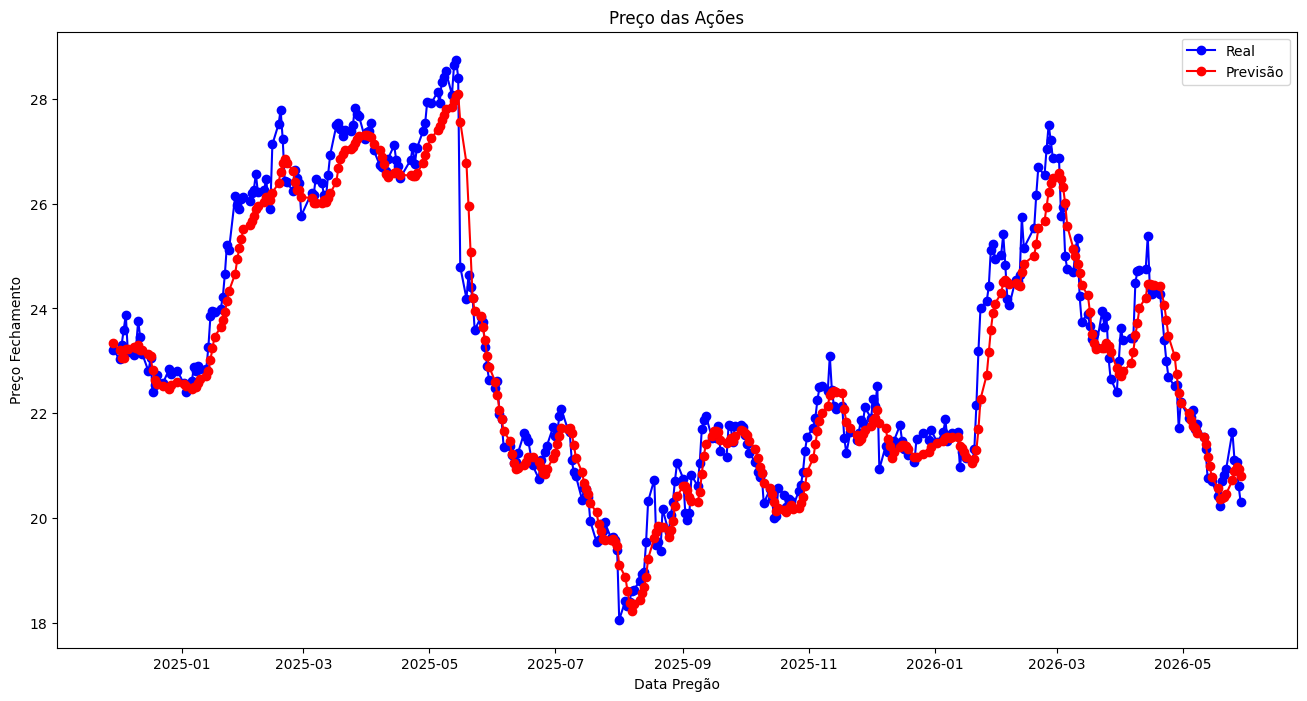

In [38]:
# Gera o gráfico comparando preço real vs. previsto
plt.figure(figsize=(16, 8))
plt.title('Preço das Ações — Abordagem 1 (y não normalizado)')
plt.plot(df['Real'],    label='Real',    color='blue', marker='o')
plt.plot(df['Previsão'], label='Previsão', color='red',  marker='o')
plt.xlabel('Data Pregão')
plt.ylabel('Preço Fechamento (R$)')
leg = plt.legend()


## 18. Abordagem 2 — Modelo com normalização do alvo (y)

Nesta segunda abordagem, além de normalizar as features **X**, também normalizamos o alvo **y** antes do treino e desnormalizamos após a previsão.

**Por que normalizar y?**  
Quando y tem escala muito diferente das features, a rede neural pode ter dificuldade em ajustar os pesos de forma eficiente. Normalizar y coloca alvo e features na mesma escala relativa, podendo melhorar a convergência.

**Passos:**
1. Normaliza X com `StandardScaler` (média 0, desvio padrão 1)
2. Normaliza y com `StandardScaler`
3. Treina a rede com X e y normalizados
4. Gera previsões (resultado normalizado)
5. **Desnormaliza** as previsões para voltar à escala original em R$

In [ ]:
# ── Abordagem 2: normaliza tanto X quanto y 

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# ── Passo 1: Normaliza X com StandardScaler (média=0, desvio padrão=1) 
scaler_x = StandardScaler()
x_training_normal = scaler_x.fit_transform(x_training)  # aprende + transforma
x_test_normal     = scaler_x.transform(x_test)           # só transforma

# ── Passo 2: Normaliza y com StandardScaler 
scaler_y = StandardScaler()
# reshape(-1, 1) converte de array 1D para 2D (exigido pelo scaler)
y_training_normal = scaler_y.fit_transform(y_training.values.reshape(-1, 1))

# ── Passo 3: Treina a rede neural com X e y normalizados 
rn = MLPRegressor(max_iter=2000, random_state=42)
# ravel() converte de 2D de volta para 1D (necessário para o MLPRegressor)
rn.fit(x_training_normal, y_training_normal.ravel())

# ── Passo 4: Gera previsões (resultado ainda na escala normalizada) 
predict_normalizado = rn.predict(x_test_normal)

# ── Passo 5: Desnormaliza a previsão para a escala original (R$) 
predict = scaler_y.inverse_transform(predict_normalizado.reshape(-1, 1)).ravel()

# Calcula R² comparando previsão desnormalizada com y real
cd = r2_score(y_test, predict)
f'Coeficiente de determinação: {cd * 100:.2f}'


'Coeficiente de determinação:90.18'

## 19. Tabela de resultados — Abordagem 2

In [47]:
# Cria o DataFrame de comparação com a previsão desnormalizada
df = pd.DataFrame({
    'Data_Pregão': data.loc[x_test.index, 'Date'],
    'Real'       : y_test.values,
    'Previsão'   : predict
})

df.set_index('Data_Pregão', inplace=True)
df

,Real,Previsão
Data_Pregão,,
2024-11-29 00:00:00-03:00,23.21,22.87
2024-12-02 00:00:00-03:00,23.03,22.74
2024-12-03 00:00:00-03:00,23.31,22.58
2024-12-04 00:00:00-03:00,23.59,22.57
2024-12-05 00:00:00-03:00,23.88,22.78
...,...,...
2026-05-25 00:00:00-03:00,21.65,20.45
2026-05-26 00:00:00-03:00,21.11,20.67
2026-05-27 00:00:00-03:00,21.07,20.76


## 20. Gráfico — Abordagem 2 (com normalização do y)

Visualizamos novamente o preço real vs. previsto com o modelo aprimorado.

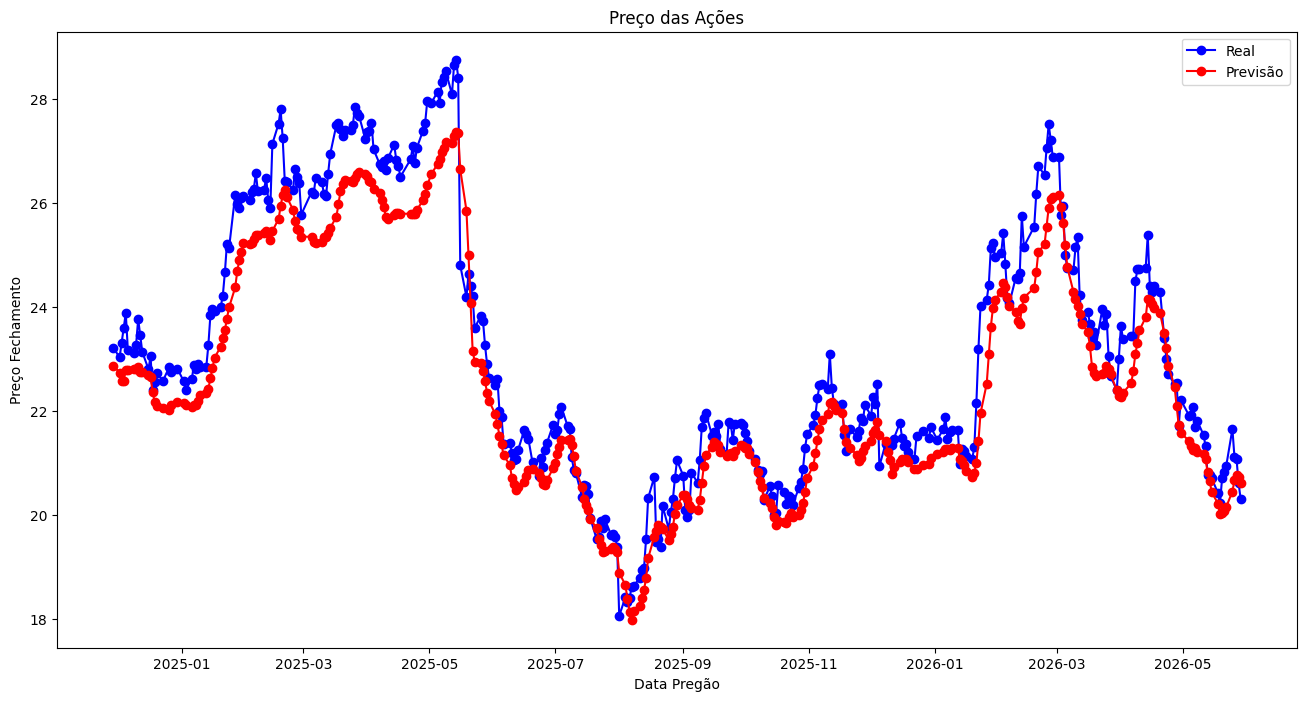

In [48]:
# Gera o gráfico comparando preço real vs. previsto (Abordagem 2)
plt.figure(figsize=(16, 8))
plt.title('Preço das Ações — Abordagem 2 (y normalizado)')
plt.plot(df['Real'],    label='Real',    color='blue', marker='o')
plt.plot(df['Previsão'], label='Previsão', color='red',  marker='o')
plt.xlabel('Data Pregão')
plt.ylabel('Preço Fechamento (R$)')
leg = plt.legend()
